#### Independent Variables (Features): City Services, Housing Cost, Quality of Schools, Community Trust, Community Maintenance, Availability of Community Room.
#### Dependent Variable (Target Feature): Happiness.

In [4]:
import csv
import sklearn

## TASK 1 START: Load the dataset

In [5]:
with open('HappinessData-1.csv', mode='r', newline='', encoding='utf-8') as dataset:
    dataset_parser = csv.DictReader(dataset)
    data = list(dataset_parser)

## TASK 2 START: Reorder dataset columns

In [6]:
# The target feature (happy/unhappy) will be last column
columns = list(data[0].keys())
new_column_order = columns[1:] + [columns[0]]

# Reorder all datapoints
dataset_reordered = []
for row in data:
    # Create a dictionary following the new order
    reordered_row = {key: row[key] for key in new_column_order}
    dataset_reordered.append(reordered_row)

print("New Order:", list(dataset_reordered[0].keys()))

New Order: ['City Services Availability', 'Housing Cost', 'Quality of schools', 'Community trust in local police', 'Community Maintenance', 'Availability of Community Room ', 'Unhappy/Happy']


## TASK 3 START: Handle any missing/NA values

In [7]:
print(f"Pre-clean rows: {len(dataset_reordered)}")

clean_dataset = []
for row in data:
    # If any value is empty, drop row
    if any(value == '' or value is None for value in row.values()):
        continue # Skip this row
    # Otherwise we re-add row
    reordered_row = {key: row[key] for key in new_column_order}
    clean_dataset.append(reordered_row)
    
print(f"Post-clean rows: {len(clean_dataset)}")

Pre-clean rows: 140
Post-clean rows: 136


## TASK 4 START: Pearson Correlation

In [8]:
import math
import statistics

# Turn all nums into floats
numeric_data = [[float(val) for val in row.values()] for row in clean_dataset]

# Separate input features from target
X = [row[:-1] for row in numeric_data]
y = [row[-1] for row in numeric_data]

for i in range(len(X[0])):
    # Extract individual feature column
    feature_column = [row[i] for row in X]
    feature_name = new_column_order[i]
    
    # Calculate correlation between this feature and target feature
    r_value = statistics.correlation(feature_column, y)
    
    print(f"{feature_name}: {r_value:.4f}")

City Services Availability: 0.3304
Housing Cost: 0.0245
Quality of schools: 0.1766
Community trust in local police: 0.1234
Community Maintenance: 0.2146
Availability of Community Room : 0.2123


## TASK 5 START: Implement KNN without Scikit

In [9]:
split_pos = int(len(clean_dataset) * 0.8)

# We get our input features X (all features except happy/unhappy)
# We get our target feature Y (happy/unhappy)
X = []
y = []

# Use the Pearson Correlation from before to drop columns
for row in clean_dataset:
    all_features = list(row.values())[:-1]
    # Keep the columns below
    filtered_x = [
        float(all_features[0]), # City Services
        float(all_features[2]), # Quality of schools
        float(all_features[4]), # Community Maintenance
        float(all_features[5])  # Availability of Community Room
    ]
    X.append(filtered_x)

    y.append(int(list(row.values())[-1]))

# Make the train/set sets using the split position
X_train, X_test = X[:split_pos], X[split_pos:]
y_train, y_test = y[:split_pos], y[split_pos:]

print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")

Training set: 108 rows
Testing set: 28 rows


In [10]:
# Normalize features so they all fall between 0-1
mins = [min(column) for column in zip(*X_train)]
maxs = [max(column) for column in zip(*X_train)]

def normalize_dataset(dataset, mins, maxs):
    normalized_data = []
    for row in dataset:
        new_row = []
        for i in range(len(row)):
            denom = float(maxs[i]) - float(mins[i])
            scaled_val = (float(row[i]) - float(mins[i])) / denom
            new_row.append(scaled_val)
        normalized_data.append(new_row)
    return normalized_data

# Apply normalization to both sets
X_train_norm = normalize_dataset(X_train, mins, maxs)
X_test_norm = normalize_dataset(X_test, mins, maxs)

In [11]:
# Function to find k nearest neighbors gets majority vote
def predict_classification(train_X, train_y, test_row, k, distance_func):
    distances = []
    # Calculate distance to every other row (datapoint)
    for i in range(len(train_X)):
        dist = distance_func(test_row, train_X[i])
        distances.append((train_y[i], dist))
    
    # Sort by distance
    distances.sort(key=lambda x: x[1])
    
    # Get the labels of the top k neighbors
    neighbors_labels = [distances[i][0] for i in range(k)]
    
    # Return the most common label (the "mode")
    return statistics.mode(neighbors_labels)

In [12]:
# First distance metric we use is Euclidean
def euclidean(row1, row2):
    distance = 0.0
    for i in range(len(row1)):
        distance += (float(row1[i]) - float(row2[i]))**2
    return math.sqrt(distance)

# Second distance metric is Manhattan
def manhattan(row1, row2):
    distance = 0.0
    for i in range(len(row1)):
        # Sum of absolute differences instead of squared differences
        distance += abs(float(row1[i]) - float(row2[i]))
    return distance

In [13]:
k = 3
predictions = []

# EUCLIDEAN TEST
for row in X_test_norm:
    result = predict_classification(X_train_norm, y_train, row, k, euclidean)
    predictions.append(result)

# Calculate accuracy
correct = 0
for i in range(len(y_test)):
    if y_test[i] == predictions[i]:
        correct += 1

accuracy = (correct / len(y_test))
print(f"knn Accuracy (k={k}): {accuracy:.2%}")

# Off testing:
# Best k-value is 3 with accuracy of 75%

knn Accuracy (k=3): 75.00%


In [14]:
k = 3
predictions = []

# MANHATTAN TEST
for row in X_test_norm:
    result = predict_classification(X_train_norm, y_train, row, k, manhattan)
    predictions.append(result)

# Calculate accuracy
correct = 0
for i in range(len(y_test)):
    if y_test[i] == predictions[i]:
        correct += 1

accuracy = (correct / len(y_test))
print(f"knn Accuracy (k={k}): {accuracy:.2%}")

# Off testing:
# Best k-value is 3 with accuracy of 75%

knn Accuracy (k=3): 75.00%


## TASK 6 START: Doing KNN using Scikit

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_sklearn = 5

# --------- MANHATTAN -------------

# Initialize the Scikit KNN model
knn_model = KNeighborsClassifier(n_neighbors=k_sklearn, metric='manhattan')

# Train the model using the same normalized set as earlier
knn_model.fit(X_train_norm, y_train)

# Make predictions on your testing lists
sklearn_predictions = knn_model.predict(X_test_norm)

# Calculate and print the accuracy
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-Learn KNN Accuracy Manhattan (k={k_sklearn}): {sklearn_accuracy:.2%}")

# --------- EUCLIDEAN -------------

# Now we use euclidean distance
knn_model = KNeighborsClassifier(n_neighbors=k_sklearn, metric='euclidean')

# Train the model using the same normalized set as earlier
knn_model.fit(X_train_norm, y_train)

# Make predictions on your testing lists
sklearn_predictions = knn_model.predict(X_test_norm)

# Calculate and print the accuracy
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-Learn KNN Accuracy Euclidean (k={k_sklearn}): {sklearn_accuracy:.2%}")


# Best for both euclidean & manhattan seems to be:
# k = 5 with accuracy of 64.29%

Scikit-Learn KNN Accuracy Manhattan (k=5): 46.43%
Scikit-Learn KNN Accuracy Euclidean (k=5): 50.00%


## TASK 7 START: Iterating over K values

In [36]:
# These will hold the k-values we iterate over and their accuracy.
# For example, if k = 3 is 60%, then index 2 will be 60%.
k_list_no_scikit = []
k_list_scikit = []

# We will be using EUCLIDEAN distance for both tests

# Let's fill k_list for Scikit KNN first
for k in range(1, 101):
    # Code copied from Task 6 above
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_model.fit(X_train_norm, y_train)
    sklearn_predictions = knn_model.predict(X_test_norm)
    sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
    k_list_scikit.append(sklearn_accuracy)

# Now we use the self-made KNN from Task 5
for k in range(1, 101):
    # Code copied from Task 5
    predictions = []
    for row in X_test_norm:
        result = predict_classification(X_train_norm, y_train, row, k, euclidean)
        predictions.append(result)
    correct = 0
    for i in range(len(y_test)):
        if y_test[i] == predictions[i]:
            correct += 1
    accuracy = (correct / len(y_test))
    k_list_no_scikit.append(accuracy)

print(f"        No Scikit / Scikit")
for i in range(0, 100):
    print(f"k = {i + 1} | {k_list_no_scikit[i]:.2%}, {k_list_scikit[i]:.2%}")
    


        No Scikit / Scikit
k = 1 | 60.71%, 50.00%
k = 2 | 60.71%, 39.29%
k = 3 | 35.71%, 42.86%
k = 4 | 57.14%, 35.71%
k = 5 | 46.43%, 50.00%
k = 6 | 53.57%, 60.71%
k = 7 | 50.00%, 50.00%
k = 8 | 57.14%, 57.14%
k = 9 | 60.71%, 46.43%
k = 10 | 64.29%, 53.57%
k = 11 | 46.43%, 42.86%
k = 12 | 50.00%, 50.00%
k = 13 | 42.86%, 46.43%
k = 14 | 35.71%, 46.43%
k = 15 | 35.71%, 28.57%
k = 16 | 32.14%, 35.71%
k = 17 | 32.14%, 32.14%
k = 18 | 32.14%, 35.71%
k = 19 | 35.71%, 39.29%
k = 20 | 39.29%, 57.14%
k = 21 | 35.71%, 39.29%
k = 22 | 39.29%, 46.43%
k = 23 | 35.71%, 39.29%
k = 24 | 35.71%, 42.86%
k = 25 | 39.29%, 35.71%
k = 26 | 42.86%, 42.86%
k = 27 | 35.71%, 35.71%
k = 28 | 39.29%, 46.43%
k = 29 | 42.86%, 35.71%
k = 30 | 39.29%, 42.86%
k = 31 | 39.29%, 35.71%
k = 32 | 39.29%, 32.14%
k = 33 | 42.86%, 39.29%
k = 34 | 35.71%, 39.29%
k = 35 | 39.29%, 39.29%
k = 36 | 32.14%, 35.71%
k = 37 | 35.71%, 35.71%
k = 38 | 35.71%, 28.57%
k = 39 | 39.29%, 32.14%
k = 40 | 35.71%, 32.14%
k = 41 | 39.29%, 32.14

## TASK 8 START: Plot the error rate for both KNN algos

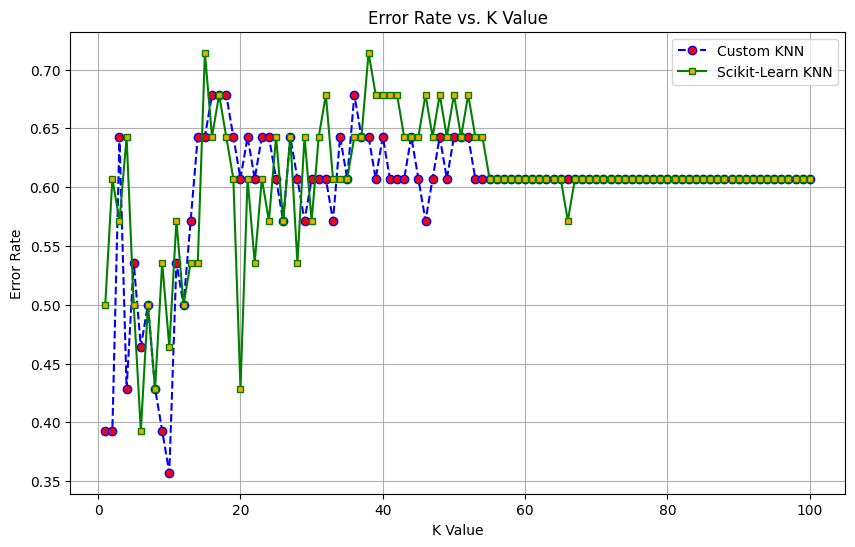

In [32]:
# We need matplotlib to make a graph
import matplotlib.pyplot as plt

# Convert accuracy to error (error = 1 - accuracy)
error_rate_no_scikit = [(1 - acc) for acc in k_list_no_scikit]
error_rate_scikit = [(1 - acc) for acc in k_list_scikit]

# K values we used above
k_values = range(1, 101)

# Set up the figure size
plt.figure(figsize=(10, 6))

# Plot the custom KNN algorithm error rate
plt.plot(k_values, error_rate_no_scikit, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=6, label='Custom KNN')

# Plot the Scikit-Learn error rate so we can compare
plt.plot(k_values, error_rate_scikit, color='green', linestyle='solid', 
         marker='s', markerfacecolor='orange', markersize=5, label='Scikit-Learn KNN')

plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)

plt.show()

### Custom-KNN: Best K-value is 10 (64.29% acc)
### Scikit KNN: Best K-value is 6 (60.71% acc)

## TASK 9 START: N-Fold Cross Validation

### Iterating over k-values again (also added another elbow graph just to compare between k-fold and 80/20).

k = 1 | N-Fold Avg Accuracy: 58.84%
k = 2 | N-Fold Avg Accuracy: 58.84%
k = 3 | N-Fold Avg Accuracy: 62.51%
k = 4 | N-Fold Avg Accuracy: 60.29%
k = 5 | N-Fold Avg Accuracy: 60.26%
k = 6 | N-Fold Avg Accuracy: 58.10%
k = 7 | N-Fold Avg Accuracy: 63.20%
k = 8 | N-Fold Avg Accuracy: 60.32%
k = 9 | N-Fold Avg Accuracy: 62.57%
k = 10 | N-Fold Avg Accuracy: 61.06%
k = 11 | N-Fold Avg Accuracy: 58.89%
k = 12 | N-Fold Avg Accuracy: 60.34%
k = 13 | N-Fold Avg Accuracy: 62.54%
k = 14 | N-Fold Avg Accuracy: 61.83%
k = 15 | N-Fold Avg Accuracy: 61.11%
k = 16 | N-Fold Avg Accuracy: 60.37%
k = 17 | N-Fold Avg Accuracy: 59.60%
k = 18 | N-Fold Avg Accuracy: 57.43%
k = 19 | N-Fold Avg Accuracy: 60.37%
k = 20 | N-Fold Avg Accuracy: 56.67%
k = 21 | N-Fold Avg Accuracy: 58.15%
k = 22 | N-Fold Avg Accuracy: 56.69%
k = 23 | N-Fold Avg Accuracy: 55.95%
k = 24 | N-Fold Avg Accuracy: 54.47%
k = 25 | N-Fold Avg Accuracy: 56.72%
k = 26 | N-Fold Avg Accuracy: 56.69%
k = 27 | N-Fold Avg Accuracy: 58.23%
k = 28 | N

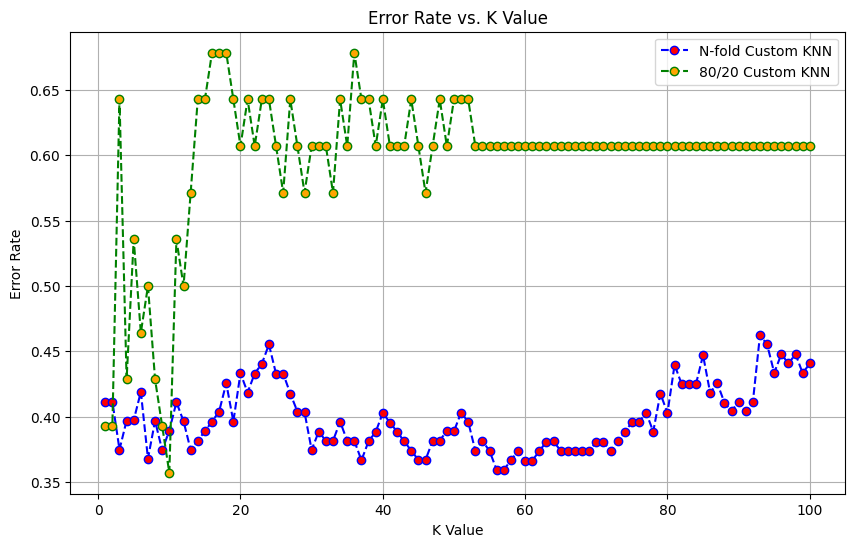

In [33]:
import random

# We set the seed for consistency, also doing 5 folds
n_folds = 5
random.seed(42)

# Prepare and shuffle the folds
# We are not using the normalized dataset from earlier
# as it could introduce bias (min/max leaks into different folds)
dataset_combined = [list(X[i]) + [y[i]] for i in range(len(X))]
random.shuffle(dataset_combined)

fold_size = len(dataset_combined) // n_folds
folds = []
for i in range(n_folds):
    if i == n_folds - 1:
        folds.append(dataset_combined[i * fold_size:])
    else:
        folds.append(dataset_combined[i * fold_size : (i + 1) * fold_size])

# Final average accuracy for every K
n_fold_k_accuracies = []

# The K loop
for k in range(1, 101):
    fold_accuracies = []
    
    # The N-fold loop
    for i in range(n_folds):
        test_fold = folds[i]
        
        train_fold = []
        for j in range(n_folds):
            if i != j:
                train_fold.extend(folds[j])
                
        # Separate features and target feature
        X_train_fold = [row[:-1] for row in train_fold]
        y_train_fold = [row[-1] for row in train_fold]
        X_test_fold = [row[:-1] for row in test_fold]
        y_test_fold = [row[-1] for row in test_fold]
        
        # Calculate min/max strictly on training fold !!!
        mins = [min(column) for column in zip(*X_train_fold)]
        maxs = [max(column) for column in zip(*X_train_fold)]
        # Then we can normalize
        X_train_norm = normalize_dataset(X_train_fold, mins, maxs)
        X_test_norm = normalize_dataset(X_test_fold, mins, maxs)
        
        # Finally we make predictions using euclidean again
        correct = 0
        for idx in range(len(X_test_norm)):
            prediction = predict_classification(X_train_norm, y_train_fold, X_test_norm[idx], k, euclidean)
            if prediction == y_test_fold[idx]:
                correct += 1
                
        # Save accuracy for this specific fold
        fold_accuracies.append(correct / len(X_test_fold))
    
    # Average the 5 folds for this specific K value
    average_accuracy_for_k = sum(fold_accuracies) / n_folds
    n_fold_k_accuracies.append(average_accuracy_for_k)
    print(f"k = {k} | N-Fold Avg Accuracy: {average_accuracy_for_k:.2%}")


# We need matplotlib to make a graph
import matplotlib.pyplot as plt

# Convert accuracy to error (error = 1 - accuracy)
error_rate_n_fold = [(1 - acc) for acc in n_fold_k_accuracies]

# K values we used above
k_values = range(1, 101)

# Set up the figure size
plt.figure(figsize=(10, 6))

# Plot the n-fold using the custom KNN
plt.plot(k_values, error_rate_n_fold, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=6, label='N-fold Custom KNN')

# Compare to 80/20
plt.plot(k_values, error_rate_no_scikit, color='green', linestyle='dashed', 
         marker='o', markerfacecolor='orange', markersize=6, label='80/20 Custom KNN')

plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)

plt.show()

### As we can see above, N-fold cross validation performs much better than doing a 80/20 train/test split.

### N-fold works best with a n-fold of **5** and a k-neighbors value of **56** (64.07% acc)
### 80/20 works best with a k-neighbors value of **10** (64.29% acc)
- 80/20 performs better than n-fold only a few times in the graph.

## TASK 10 START: Making a confusion matrix

In [37]:
# The best k was 10 from previous testing
best_k = 10
predictions = []

# Generate predictions for the test set using customer model (80/20)
for row in X_test_norm:
    result = predict_classification(X_train_norm, y_train, row, best_k, euclidean)
    predictions.append(result)

# Matrix counters
TP = 0
TN = 0
FP = 0
FN = 0

# Compare predictions against the actual values
for i in range(len(y_test)):
    actual = y_test[i]
    predicted = predictions[i]
    
    if actual == 1 and predicted == 1:
        TP += 1
    elif actual == 0 and predicted == 0:
        TN += 1
    elif actual == 0 and predicted == 1:
        FP += 1
    elif actual == 1 and predicted == 0:
        FN += 1

print(f"Confusion Matrix (k={best_k}):")
print("-" * 30)
print(f"                 | Predicted Happy (1) | Predicted Unhappy (0)")
print("-" * 30)
print(f"Actual Happy (1) | TP: {TP:<15} | FN: {FN}")
print(f"Actual Unhappy(0)| FP: {FP:<15} | TN: {TN}")
print("-" * 30)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Confusion Matrix (k=10):
------------------------------
                 | Predicted Happy (1) | Predicted Unhappy (0)
------------------------------
Actual Happy (1) | TP: 9               | FN: 2
Actual Unhappy(0)| FP: 8               | TN: 9
------------------------------
Precision: 52.94%
Recall: 81.82%
